# Esame Data Science - a.a. 2018/2019

Di seguitono sono proposti gli esercizi per la prova d'esame.
Per presentarsi all'esame è necessario aver implementato una soluzione per tutti e 3 gli esercizi.

1. [Esercizio Decision Tree](#esercizio1)
2. [Esercizio regressione](#esercizio2)
3. [Esercizio clustering e classificazione con NN](#esercizio3)

<a id="esercizio1"></a>
## Esercizio Decision Tree

Per questo primo esercizio viene richiesto di creare un Decision Tree con le librerie python e di rappresentarne il risultato per farci dei ragionamenti.

I dati da utilizzare sono contenuti nel dataset `data/student-mat.csv`, che contiene dei dati sulle abitudini di consumo di alcool di studenti portoghesi. Il dataset contiene diverse colonne descritte nella lista qui sotto:
- school - la scuola a cui è iscritto lo studente (binario: 'GP' - Gabriel Pereira o 'MS' - Mousinho da Silveira)
- sex - il genere dello studente (binario: 'F' - femmina o 'M' - maschi)
- age - l'età dello studente (numerico: da 15 a 22)
- address - il tipo di indirizzo della casa in cui abitta lo studente (binario: 'U' - urbano o 'R' - rurale)
- famsize - la dimensione della famiglia (binario: 'LE3' - minore o uguale a 3 componenti o 'GT3' - maggiore di 3 componenti)
- Pstatus - lo stato di coabitazione dello studente (binario: 'T' - che vive insieme ad altri o 'A' - che vive isolato)
- Medu - l'educazione della madre (numerico: 0 - nessuna, 1 - educazione primaria, 2 – media, 3 – superiori 4 – università o educazione superiore)
- Fedu - l'educazione del padre (numerico: 0 - nessuna, 1 - educazione primaria, 2 – media, 3 – superiori 4 – università o educazione superiore
- Mjob - il lavoro della madre (nominale: 'teacher' - insegnante, 'health' - lavori in ambito sanitario, 'services' - pubblica amministrazione, 'at_home' - casalinga o 'other' - altro)
- Fjob - il lavoro del padre (nominale: 'teacher' - insegnante, 'health' - lavori in ambito sanitario, 'services' - pubblica amministrazione, 'at_home' - casalingo o 'other' - altro)
- reason - motivo di scelta per la scuola (nominale: 'home' - vicino a casa, 'reputation' - reputazione della scuola, 'course' - preferenza per il corso o 'other' - altro)
- guardian - guardiano dello studente (nominale: 'mother' - madre, 'father' - padre o 'other' - altro)
- traveltime - tempo di trasferimento da casa a scuola (numerico: 1 - <15 min., 2 - da 15 a 30 min., 3 - da 30 min. a 1 ora, o 4 - >1 ora)
- studytime - tempo settimanale di studio (numerico: 1 - <2 ore, 2 - da 2 a 5 ore, 3 - da 5 a 10 ore, o 4 - >10 ore)
- failures - numero dei passati fallimenti in classe (numerico: n se 1<=n<3, altrimenti 4)
- schoolsup - ripetizioni (binario: yes o no)
- famsup - supporto educativo da parte della famiglia (binario: yes o no)
- paid - classi pagate aggiuntive sul corso (matematica) (binario: yes o no)
- activities - attività extra-curricularari (binario: yes o no)
- nursery - ha frequentato l'asilo nido (binario: yes o no)
- higher - vuole frequentare l'università (binario: yes o no)
- internet - ha accesso a internat da casa (binario: yes o no)
- romantic - è in una relazione sentimentale (binario: yes o no)
- famrel - qualità delle relazioni famigliari (numerico: da 1 - molto cattive a 5 - eccellenti)
- freetime - tempo libero dopo scuola (numerico: da 1 - molto poco a 5 - molto)
- goout - esce con gli amici (numerico: da 1 - molto poco a 5 - molto spesso)
- Dalc - consumo di alcool in giorni infrasettimanali (numerico: da 1 - molto poco a 5 - molto)
- Walc - consumo di alcool durante i weekend (numerico: da 1 - molto poco a 5 - molto)
- health - stato attuale di salute (numerico: da 1 - pessimo a 5 - ottimo)
- absences - numero di assenze da scuola (numerico: da 0 a 93)

Questi voti, quindi, rappresentano il rendimento scolastico. In particolare questi voti sono relativi al corso di matematica:
- G1 - voto del primo semestre (numerico: da 0 a 20)
- G2 - voto del secondo semestre (numerica: da 0 a 20)
- G3 - voto finale (numerico: da 0 a 20)

Per l'esercizio è richiesto di creare un albero di decisione che descriva quali variabili influiscono maggiormente sul consumo alcolico nei ragazzi.

L'albero può essere troncato ad una profondità di qualche livello e deve essere allegato e discusso con alcune considerazioni sul dataset.

Dopo la realizzazione dell'albero, viene richiesto di disegnarlo e caricare l'immagine nel notebook (è possibile utilizzare il sito internet visto a lezione (http://webgraphviz.com).
I risultati ottenuti nell'albero devono essere quindi brevemente commentati.

In [1]:
import pandas as pd
data = pd.read_csv('data/student-mat.csv')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Guardiamo un po' il dataset:

In [2]:
data.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [3]:
columns = data.columns
numerical = data.describe().columns
categorical = [f for f in columns if f not in numerical]

In [4]:
data[numerical].describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
data[categorical]

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,yes,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,yes,no,yes,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,U,LE3,A,services,services,course,other,no,yes,yes,no,yes,yes,no,no
391,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no
392,MS,M,R,GT3,T,other,other,course,other,no,no,no,no,no,yes,no,no
393,MS,M,R,LE3,T,services,other,course,mother,no,no,no,no,no,yes,yes,no


In [6]:
from sklearn.preprocessing import LabelEncoder
for label in categorical:
    data[label] = LabelEncoder().fit_transform(data[label])
    
data[categorical]

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,0,0,1,0,0,0,4,0,1,1,0,0,0,1,1,0,0
1,0,0,1,0,1,0,2,0,0,0,1,0,0,0,1,1,0
2,0,0,1,1,1,0,2,2,1,1,0,1,0,1,1,1,0
3,0,0,1,0,1,1,3,1,1,0,1,1,1,1,1,1,1
4,0,0,1,0,1,2,2,1,0,0,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,1,1,0,3,3,0,2,0,1,1,0,1,1,0,0
391,1,1,1,1,1,3,3,0,1,0,0,0,0,0,1,1,0
392,1,1,0,0,1,2,2,0,2,0,0,0,0,0,1,0,0
393,1,1,0,1,1,3,2,0,1,0,0,0,0,0,1,1,0


Calcoliamo un indice relativo al consumo di alcool (sia durante i giorni lavorativi, che durante il weekend):

In [7]:
data['alcool'] = (data['Dalc'] + data['Walc']) / 2
data[['Dalc', 'Walc', 'alcool']].head()

,Dalc,Walc,alcool
0,1,1,1.0
1,1,1,1.0
2,2,3,2.5
3,1,1,1.0
4,1,2,1.5


In [8]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = data.drop(['Dalc', 'Walc', 'alcool'], axis=1)
y = data['alcool'].map(lambda x: 1 if x >= 3 else 0)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

Decision tree per capire cosa induce al consumo di alcool:

In [9]:
dct = DecisionTreeClassifier(max_depth=3)
dct.fit(x_train, y_train)

tree.export_graphviz(dct,
                     out_file='data/tree.dot',
                     impurity=False,
                     feature_names=X.columns,
                     class_names=['Sober', 'Drunk'],
                     rounded=True,
                     filled=True)

<img src="img/AlcoolTree.png"/>

In [10]:
def print_results(df):
    right = df.loc[df['prediction'] == df['label']]
    wrong = df.loc[df['prediction'] != df['label']]

    true_positive = right.loc[right['prediction'] == 1]
    false_positive = wrong.loc[wrong['prediction'] == 1]
    false_negative = wrong.loc[wrong['prediction'] == 0]

    print("We had %d elements in our recordset." % len(df))
    print("We classified correctly %d events." % len(right))
    print("We classified wrongly %d events." % len(wrong))
    print("We had %d false positive and %d false negative." % (len(false_positive), len(false_negative)))

    print("")

    print("Our precision has been %1.2f." % (len(true_positive)/(len(true_positive) + len(false_positive))))
    print("Our recall has been %1.2f." % (len(true_positive)/(len(true_positive) + len(false_negative))))
    

print("###### PRINTING DATA FROM TRAIN SET:")
df_train = pd.DataFrame({
    'prediction': dct.predict(x_train),
    'label': y_train
})
print_results(df_train)

print("")

print("###### PRINTING DATA FROM TEST SET:")
df_test = pd.DataFrame({
    'prediction': dct.predict(x_test),
    'label': y_test
})
print_results(df_test)

###### PRINTING DATA FROM TRAIN SET:
We had 276 elements in our recordset.
We classified correctly 245 events.
We classified wrongly 31 events.
We had 11 false positive and 20 false negative.

Our precision has been 0.75.
Our recall has been 0.62.

###### PRINTING DATA FROM TEST SET:
We had 119 elements in our recordset.
We classified correctly 95 events.
We classified wrongly 24 events.
We had 11 false positive and 13 false negative.

Our precision has been 0.42.
Our recall has been 0.38.


<a id="esercizio2"></a>
## Esercizio regressione

Questo secondo esercizio richiede di effettuare una regressione lineare con una o più variabili.

Leggendo il dataset `data/adminisson.csv`, caricare i dati gli gli esiti dei vari test di studenti americani. Per ogni studente, il dataset roporta la probabilità di essere ammesso alla scuola a cui ha fatto application.

L'esercizio chiede di creare un modello di regressione che, considerando i risultati dei test, sia in grado di prevedere le probabilità di ammissione.

Il modello deve essere creato con tutte le variabili indipendenti presenti nel dataset *(in questo caso, però, non sarà possibile effettuarne una rappresentazione grafica)*. In questo caso, tuttavia, sarà possibile creare il modello e discuerne la qualità di predizione.

In aggiunta, è richiesto di selezionare il test (o al massimo i 2 test) che correlano maggiormente con la probabilità di essere ammesso alla scuola e quindi di fare una nuova regressione solo con quella (o quelle) variabili in modo che sia rappresentatbile graficamente con un grafico scatter.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os

In [12]:
df = pd.read_csv("data/admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Creiamo la matrice di correlazione come grafico.

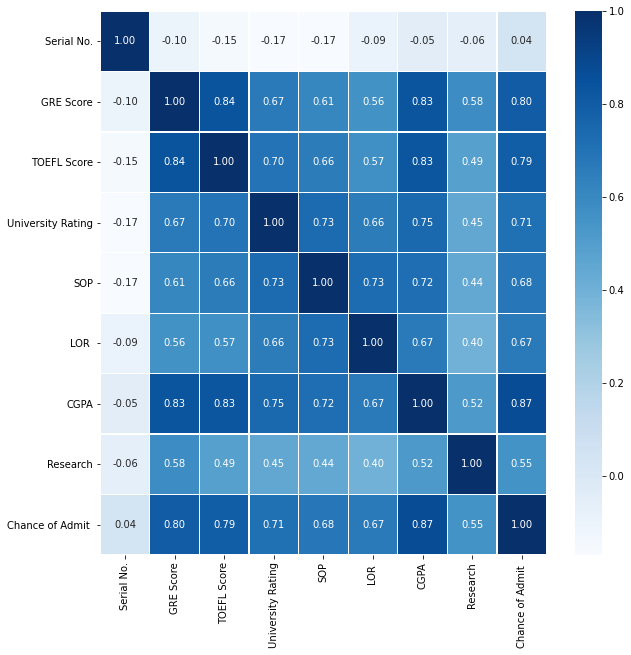

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df.corr(), ax=ax, annot=True, linewidths=0.05, fmt='.2f', cmap=plt.cm.Blues)
plt.show()

Rappresentiamo tutti i grafici scatter:

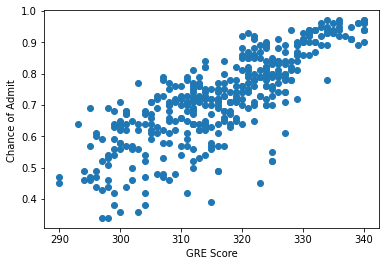

In [14]:
plt.scatter(df['GRE Score'], df['Chance of Admit '])
plt.xlabel('GRE Score')
plt.ylabel('Chance of Admit ')
plt.show()

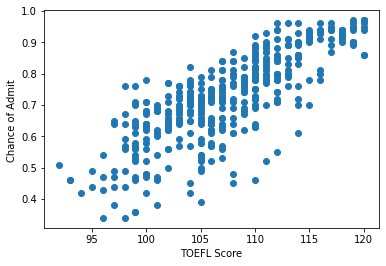

In [15]:
plt.scatter(df['TOEFL Score'], df['Chance of Admit '])
plt.xlabel('TOEFL Score')
plt.ylabel('Chance of Admit ')
plt.show()

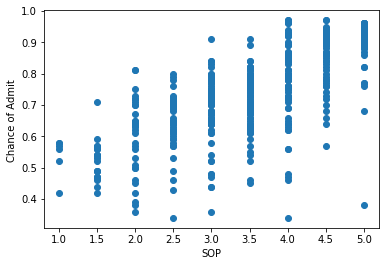

In [16]:
plt.scatter(df['SOP'], df['Chance of Admit '])
plt.xlabel('SOP')
plt.ylabel('Chance of Admit ')
plt.show()

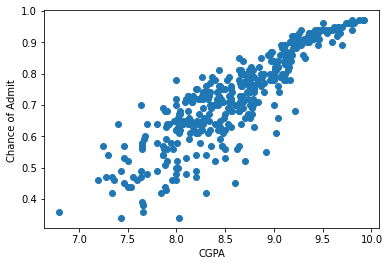

In [17]:
plt.scatter(df['CGPA'], df['Chance of Admit '])
plt.xlabel('CGPA')
plt.ylabel('Chance of Admit ')
plt.show()

Ripuliamo un po' il dataset:

In [18]:
serialNo = df["Serial No."].values
df.drop(["Serial No."], axis=1, inplace=True)

y = df["Chance of Admit "].values
x = df.drop(["Chance of Admit "], axis=1)

Dividiamo il dataset tra training e test e scaliamo i dati.

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [20]:
from sklearn.preprocessing import MinMaxScaler

pd.options.mode.chained_assignment = None
scalerX = MinMaxScaler(feature_range=(0, 1))

x_train[x_train.columns] = scalerX.fit_transform(x_train[x_train.columns])
x_test[x_test.columns] = scalerX.transform(x_test[x_test.columns])

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(x_train, y_train)

y_test_p = lr.predict(x_test)
y_train_p = lr.predict(x_train)

print("r_square score (test) : %.4f" % r2_score(y_test, y_test_p))
print("r_square score (train): %.4f" % r2_score(y_train, y_train_p))

r_square score (test) : 0.7827
r_square score (train): 0.8071


I due test che correlano maggiormente con la possibilità di essere ammessi sono il GRE e il CAGR.

Proviamo a procedere alla regressione di entrambi.

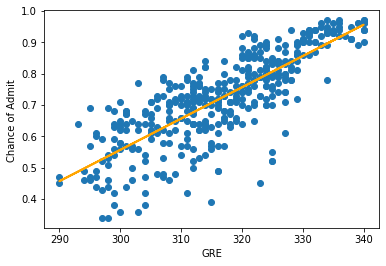

In [22]:
from sklearn.linear_model import LinearRegression

x_gre = df[['GRE Score']].values
y = df['Chance of Admit '].values

regr = LinearRegression()
regr.fit(x_gre, y)
yhat = regr.predict(x_gre)

plt.scatter(x_gre, y)
plt.plot(x_gre, yhat, lw=2, c='orange')
plt.xlabel('GRE')
plt.ylabel('Chance of Admit ')
plt.show()

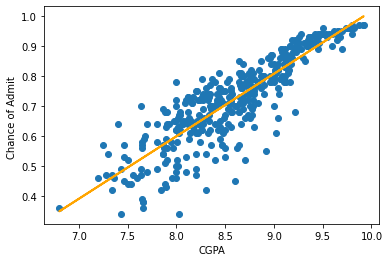

In [23]:
from sklearn.linear_model import LinearRegression

x_cgpa = df[['CGPA']].values
y = df['Chance of Admit '].values

regr = LinearRegression()
regr.fit(x_cgpa, y)
yhat = regr.predict(x_cgpa)

plt.scatter(x_cgpa, y)
plt.plot(x_cgpa, yhat, lw=2, c='orange')
plt.xlabel('CGPA')
plt.ylabel('Chance of Admit ')
plt.show()

Ora proviamo a fare una regressione doppia considerando entrambe le variabili:

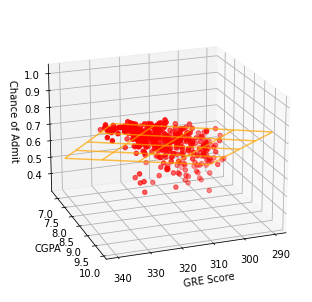

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = Axes3D(fig)

ax.scatter(df['GRE Score'], df['CGPA'], df['Chance of Admit '], color='red')
ax.set_xlabel('GRE Score')
ax.set_ylabel('CGPA')
ax.set_zlabel('Chance of Admit ')

x = np.linspace(df['GRE Score'].min(), df['GRE Score'].max(), 5)
y = np.linspace(df['CGPA'].min(), df['CGPA'].max(), 5)
x, y = np.meshgrid(x, y)

regr = LinearRegression()
regr.fit(df[['GRE Score', 'CGPA']], df['Chance of Admit '])

z = []
for i in range(5):
    row = regr.predict(pd.DataFrame({'GRE Score': x[i], 'CGPA': y[i]}))
    z.append(row)
z = np.array(z)
    
ax.view_init(20, 70)
ax.plot_wireframe(x, y, z, color='orange', alpha=0.7)
plt.show()

<a id="esercizio3"></a>
## Esercizio clustering e classificazione con NN

In questo terzo esercizio viene proposso un esercizio di clusterizzazione e di predizione con Rete Neurale.

Da principio, per questo esercizio, leggiamo il dataset `data/wine.csv`, che contiene le caratteristiche di alcune tipologie di vino. I dati contengono i seguenti attributi:

- Alcohol 
- Malic acid 
- Ash 
- Alcalinity of ash 
- Magnesium 
- Total phenols 
- Flavanoids 
- Nonflavanoid phenols 
- Proanthocyanins 
- Color intensity 
- Hue 
- OD280/OD315 of diluted wines 
- Proline 

L'esercizio chiede quindi di provare a prendere questi dati e di farne una clusterizzazione.
Le dimensioni da usare per la clusterizzazione, e per la rappresentazione scatter, sono `phenols` e `alcohol`.

Quanti gruppi convinene creare? Per scegliere questa dimensione è necessario utilizzare il metodo elbow o il metodo silhouette.
Rappresentare i dati clusterizzati.

Dopo aver fatto questa clusterizzazione è possibile leggere il dataset `data/wine-with-answers.csv`. Questo dataset è uguale al precedente ma aggiunge una colonna, la colonna `class`. Questa colonna rappresenta una classificazione dei vini fatta da un esperto enologo in tre classi (1, 2 o 3) in base alle caratteristiche del vino stesso.

L'esercizio chiede a questo punto di creare una rete neurale in grado di apprendere in modo supervised le classificazioni dei vini partendo dai loro 13 attributi.

Creare il modello, farlo apprendere e valutarne l'accuratezza su un insieme di test dei dati.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('data/wine.csv')
data.head()

,alcohol,malic_acid,ash,alcalinity_ash,agnesium,phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted,proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


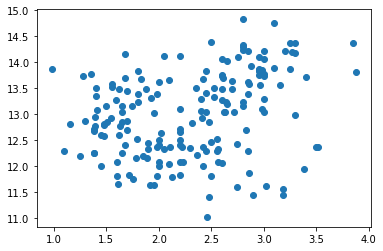

In [26]:
x = data[['phenols', 'alcohol']].copy()
plt.scatter(x['phenols'], x['alcohol'])
plt.show()

Eseguiamo il metodo elbow per stimare il numero di cluster da andare a creare:

In [27]:
from sklearn.cluster import KMeans

wcss=[]

# Create all possible cluster solutions with a loop
for i in range(1,7):
    # Cluster solution with i clusters
    kmeans = KMeans(i)
    # Fit the data
    kmeans.fit(x)
    # Find WCSS for the current iteration
    wcss_iter = kmeans.inertia_
    # Append the value to the WCSS list
    wcss.append(wcss_iter)

Text(0, 0.5, 'Within-cluster Sum of Squares')

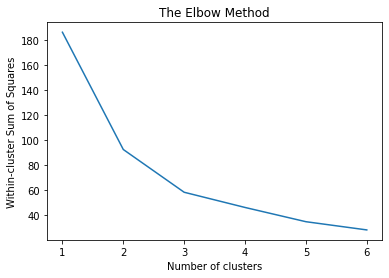

In [28]:
number_clusters = range(1, 7)
plt.plot(number_clusters,wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster Sum of Squares')

Usiamo il metodo silhouette per stimare il numero di cluster da andare a creare:

For n_clusters = 2 The average silhouette_score is : 0.43778899472390753
For n_clusters = 3 The average silhouette_score is : 0.4391961492312298
For n_clusters = 4 The average silhouette_score is : 0.39879657524827034
For n_clusters = 5 The average silhouette_score is : 0.38422408543315395
For n_clusters = 6 The average silhouette_score is : 0.3934929773467561


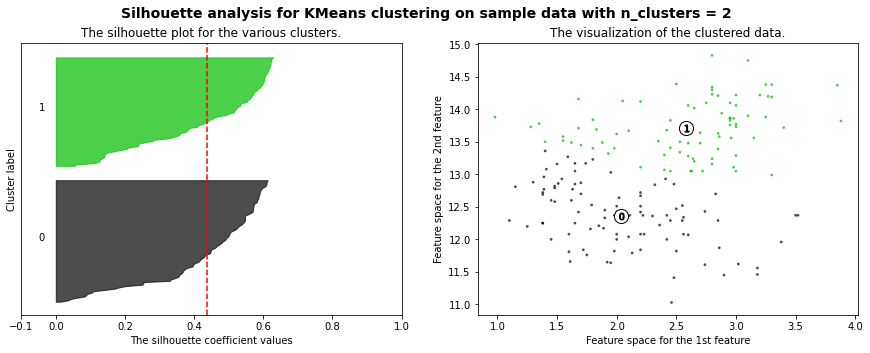

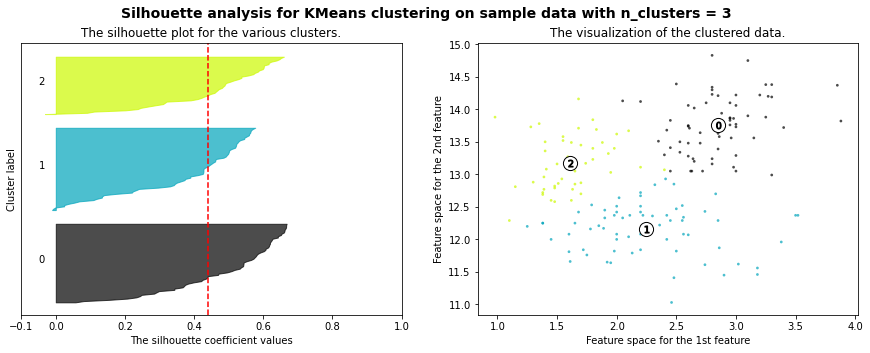

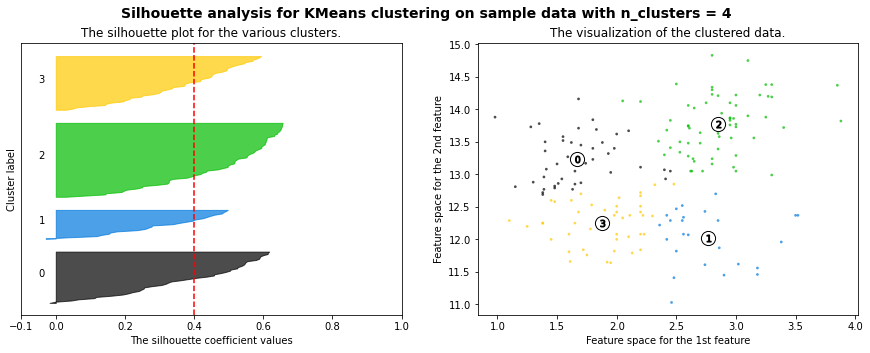

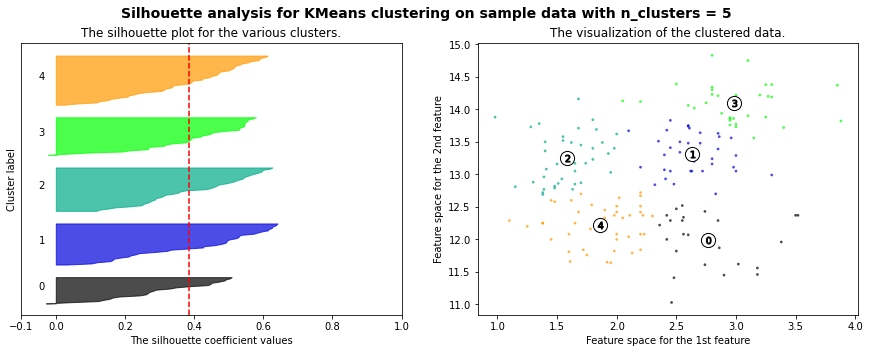

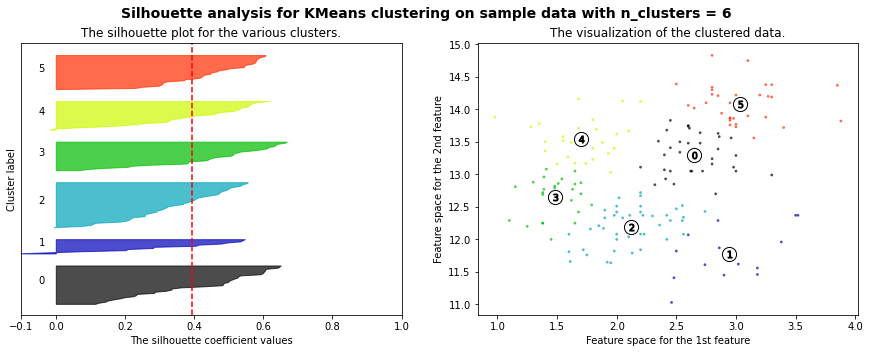

In [29]:
import numpy as np
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

for n_clusters in range(2, 7):
    clusterer = KMeans(n_clusters)
    cluster_labels = clusterer.fit_predict(x)
    
    silhouette_avg = silhouette_score(x, cluster_labels)
    sample_silhouette_values = silhouette_samples(x, cluster_labels)
    
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)
    
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15, 5)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(x) + (n_clusters + 1) * 10])
    
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples
    
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(x.iloc[:, 0], x.iloc[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

Il numero migliore di cluster sembra essere 3, quindi procediamo alla visualizzazione con KMeans:

In [30]:
kmeans = KMeans(3)
kmeans.fit(x)

identified_clusters = kmeans.fit_predict(x)
data_with_clusters = x.copy()
data_with_clusters['Cluster'] = identified_clusters

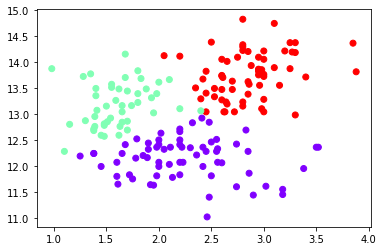

In [31]:
plt.scatter(data_with_clusters['phenols'], data_with_clusters['alcohol'], c=data_with_clusters['Cluster'], cmap='rainbow')
plt.show()

Leggiamo ora il dataset completo e procediamo alla creazione di una rete in grado di stimare la classe di appartenenza dei vini in input:

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer

data = pd.read_csv('data/wine-with-answers.csv')
data

,class,alcohol,malic_acid,ash,alcalinity_ash,agnesium,phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [33]:
X = data.drop(['class'], axis=1).copy()
Y = data['class'].copy()

ss = StandardScaler()
ll = LabelBinarizer()

X = ss.fit_transform(X)
Y = ll.fit_transform(Y)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(units=13, input_dim=13, activation='relu'))
model.add(Dense(units=10, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [35]:
"""
Visualizzazione rete neurale

Codice riadattato dalla funzione visualize.py contenuta nel pacchetto ann_visualizer creato da
ProdiCode.

Il codice crea un grafo dal modello Keras attraverso la libreria webgraph, lo salva in un file
in formato .gv e lo visualizza attraverso lo strumento di visualizzazione predefinito di
sistema per poi essere savato in un file dal formato comune (.pdf, .png, .svg) per essere poi
importato nel notebook.

"""
from tensorflow import keras
from graphviz import Digraph

input_layer = 0
hidden_layers_nr = 0
layer_types = []
hidden_layers = []
output_layer = 0
    
for layer in model.layers:
    if(layer == model.layers[0]):
        input_layer = int(str(layer.input_shape).split(",")[1][1:-1])
        hidden_layers_nr += 1
        if (type(layer) == keras.layers.Dense):
            hidden_layers.append(int(str(layer.output_shape).split(",")[1][1:-1]))
            layer_types.append("Dense")
        else:
            hidden_layers.append(1)
            if (type(layer) == keras.layers.Conv2D):
                layer_types.append("Conv2D")
            elif (type(layer) == keras.layers.MaxPooling2D):
                layer_types.append("MaxPooling2D")
            elif (type(layer) == keras.layers.Dropout):
                layer_types.append("Dropout")
            elif (type(layer) == keras.layers.Flatten):
                layer_types.append("Flatten")
            elif (type(layer) == keras.layers.Activation):
                layer_types.append("Activation")
    else:
        if(layer == model.layers[-1]):
            output_layer = int(str(layer.output_shape).split(",")[1][1:-1])
        else:
            hidden_layers_nr += 1
            if (type(layer) == keras.layers.Dense):
                hidden_layers.append(int(str(layer.output_shape).split(",")[1][1:-1]))
                layer_types.append("Dense")
            else:
                hidden_layers.append(1)
                if (type(layer) == keras.layers.Conv2D):
                    layer_types.append("Conv2D")
                elif (type(layer) == keras.layers.MaxPooling2D):
                    layer_types.append("MaxPooling2D")
                elif (type(layer) == keras.layers.Dropout):
                    layer_types.append("Dropout")
                elif (type(layer) == keras.layers.Flatten):
                    layer_types.append("Flatten")
                elif (type(layer) == keras.layers.Activation):
                    layer_types.append("Activation")
    last_layer_nodes = input_layer
    nodes_up = input_layer
    if(type(model.layers[0]) != keras.layers.Dense):
        last_layer_nodes = 1
        nodes_up = 1
        input_layer = 1

    g = Digraph('g', filename="./wine_network.gv")
    n = 0
    g.graph_attr.update(splines="false", nodesep='1', ranksep='2')
    #Input Layer
    with g.subgraph(name='cluster_input') as c:
        if(type(model.layers[0]) == keras.layers.Dense):
            the_label = 'Wine Neural Network' + '\n\n\n\nInput Layer'
            if (int(str(model.layers[0].input_shape).split(",")[1][1:-1]) > 10):
                the_label += " (+"+str(int(str(model.layers[0].input_shape).split(",")[1][1:-1]) - 10)+")"
                input_layer = 10
            c.attr(color='white')
            for i in range(0, input_layer):
                n += 1
                c.node(str(n))
                c.attr(label=the_label)
                c.attr(rank='same')
                c.node_attr.update(color="indigo", style="filled", fontcolor="indigo", shape="circle")
                
    for i in range(0, hidden_layers_nr):
            with g.subgraph(name="cluster_"+str(i+1)) as c:
                if (layer_types[i] == "Dense"):
                    c.attr(color='white')
                    c.attr(rank='same')
                    #If hidden_layers[i] > 10, dont include all
                    the_label = ""
                    if (int(str(model.layers[i].output_shape).split(",")[1][1:-1]) > 10):
                        the_label += " (+"+str(int(str(model.layers[i].output_shape).split(",")[1][1:-1]) - 10)+")"
                        hidden_layers[i] = 10
                    c.attr(labeljust="right", labelloc="b", label=the_label)
                    for j in range(0, hidden_layers[i]):
                        n += 1
                        c.node(str(n), shape="circle", style="filled", color="moccasin", fontcolor="moccasin")
                        for h in range(nodes_up - last_layer_nodes + 1 , nodes_up + 1):
                            g.edge(str(h), str(n))
                    last_layer_nodes = hidden_layers[i]
                    nodes_up += hidden_layers[i]
                    
    with g.subgraph(name='cluster_output') as c:
            if (type(model.layers[-1]) == keras.layers.Dense):
                c.attr(color='white')
                c.attr(rank='same')
                c.attr(labeljust="1")
                for i in range(1, output_layer+1):
                    n += 1
                    c.node(str(n), shape="circle", style="filled", color="#e74c3c", fontcolor="#e74c3c")
                    for h in range(nodes_up - last_layer_nodes + 1 , nodes_up + 1):
                        g.edge(str(h), str(n))
                c.attr(label='Output Layer', labelloc="bottom")
                c.node_attr.update(color="coral", style="filled", fontcolor="coral", shape="circle")

    g.attr(arrowShape="none")
    g.edge_attr.update(arrowhead="none", color="#707070")
    g.view()

In [36]:
history = model.fit(x_train, y_train, epochs=120, validation_data=(x_test, y_test))

Epoch 1/120
5/5 [==============================] - 0s 33ms/step - loss: 1.1203 - accuracy: 0.3239 - val_loss: 1.0758 - val_accuracy: 0.3889
Epoch 2/120
5/5 [==============================] - 0s 5ms/step - loss: 1.0882 - accuracy: 0.3239 - val_loss: 1.0435 - val_accuracy: 0.3889
Epoch 3/120
5/5 [==============================] - 0s 5ms/step - loss: 1.0547 - accuracy: 0.3380 - val_loss: 1.0062 - val_accuracy: 0.3889
Epoch 4/120
5/5 [==============================] - 0s 6ms/step - loss: 1.0185 - accuracy: 0.4296 - val_loss: 0.9692 - val_accuracy: 0.4722
Epoch 5/120
5/5 [==============================] - 0s 5ms/step - loss: 0.9829 - accuracy: 0.5141 - val_loss: 0.9316 - val_accuracy: 0.5556
Epoch 6/120
5/5 [==============================] - 0s 6ms/step - loss: 0.9457 - accuracy: 0.5563 - val_loss: 0.8944 - val_accuracy: 0.5833
Epoch 7/120
5/5 [==============================] - 0s 8ms/step - loss: 0.9101 - accuracy: 0.6127 - val_loss: 0.8534 - val_accuracy: 0.5833
Epoch 8/120
5/5 [=========

5/5 [==============================] - 0s 7ms/step - loss: 0.0094 - accuracy: 1.0000 - val_loss: 0.0197 - val_accuracy: 1.0000
Epoch 118/120
5/5 [==============================] - 0s 6ms/step - loss: 0.0092 - accuracy: 1.0000 - val_loss: 0.0195 - val_accuracy: 1.0000
Epoch 119/120
5/5 [==============================] - 0s 5ms/step - loss: 0.0090 - accuracy: 1.0000 - val_loss: 0.0192 - val_accuracy: 1.0000
Epoch 120/120
5/5 [==============================] - 0s 6ms/step - loss: 0.0088 - accuracy: 1.0000 - val_loss: 0.0190 - val_accuracy: 1.0000


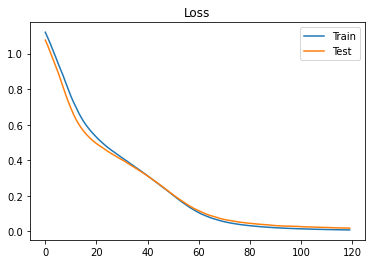

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Test'])
plt.show()

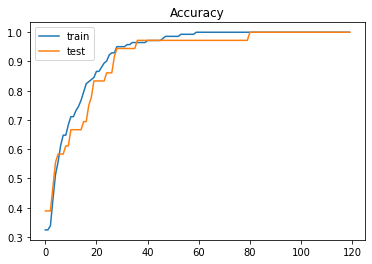

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['train', 'test'])
plt.show()

###### PRINTING DATA FROM TRAIN SET:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000        46
           2      1.000     1.000     1.000        56
           3      1.000     1.000     1.000        40

    accuracy                          1.000       142
   macro avg      1.000     1.000     1.000       142
weighted avg      1.000     1.000     1.000       142



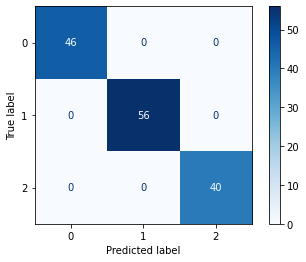

In [39]:
from sklearn import metrics

print("###### PRINTING DATA FROM TRAIN SET:")
print(metrics.classification_report(
    ll.inverse_transform(y_train),
    ll.inverse_transform(model.predict(x_train)),
    digits=3
))

cm = metrics.confusion_matrix(
    ll.inverse_transform(y_train),
    ll.inverse_transform(model.predict(x_train))
)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)


###### PRINTING DATA FROM TEST SET:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000        13
           2      1.000     1.000     1.000        15
           3      1.000     1.000     1.000         8

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



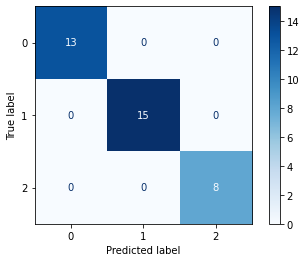

In [40]:
from sklearn import metrics


print("")

print("###### PRINTING DATA FROM TEST SET:")
print(metrics.classification_report(
    ll.inverse_transform(y_test),
    ll.inverse_transform(model.predict(x_test)),
    digits=3
))

cm = metrics.confusion_matrix(
    ll.inverse_transform(y_test),
    ll.inverse_transform(model.predict(x_test))
)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

That's all folks!